## Black-Scholes Analytical Price

In [24]:
# importing packages
import numpy as np
import scipy.stats as stats
def black_scholes_call(S0, K, T, r, sigma):
    """ 
    Calculates the analytical Black-Scholes price for a European Call Option.
    """
    # Defensive programming: Boundary checks
    if sigma <= 0: 
        raise ValueError(f"Volatility (sigma) must be strictly positive.")
    if K <= 0:
        raise ValueError(f"Strike price (K) must be strictly positive.")
    if S0 < 0 or T < 0:
        raise ValueError(f"Stock price (S0) and Time (T) cannot be negative.")
    # Calculate d1 and d2
    d_1 = (np.log(S0 / K) + (r + (sigma**2) / 2) * T) / (sigma * np.sqrt(T))
    d_2 = d_1 - sigma * np.sqrt(T)
        
    # Calculate the cummulative distribution function for d1 and d2
    N_1 = stats.norm.cdf(d_1)
    N_2 = stats.norm.cdf(d_2)

    # Calculate the Call price
    C = S0 * N_1 - K * np.exp(-r * T) * N_2
    
    return(C)

In [25]:
# Testing the function
analytical_price = black_scholes_call(100, 100, 1.0, 0.05, 0.20)
print(f"Analytical Black-Scholes Price: ${analytical_price: .4f}")

Analytical Black-Scholes Price: $ 10.4506


## Monte Carlo Convergence Engine

In [26]:
def monte_carlo_call(S0, K, T, r, sigma, M):
    """
    Calculates the price of a European Call Option using Monte Carlo simulation.
    M = Number of simulated paths
    """
    # 1. Simulate the random shocks for all paths at the terminal date T
    Z = np.random.standard_normal(M)
    
    # 2. Vectorized calculation of terminal prices (ST) using the GBM exact solution 
    ST = S0 * np.exp((r - (1/2) * sigma**2) * T + sigma * np.sqrt(T) *Z)

    # 3. Calculate the payoff for all paths
    payoffs = np.maximum(ST-K,0)

    # 4. Average the payoffs and discount back to present value
    MC_price = np.exp(-r * T) * np.mean(payoffs)

    return(MC_price)

In [27]:
# Testing the function
mc_price = monte_carlo_call(100, 100, 1.0, 0.05, 0.20, 100000)
print(f"Montel Carlo Simulated Price: ${mc_price: .4f}")

Montel Carlo Simulated Price: $ 10.3889


## The Convergence Proof 

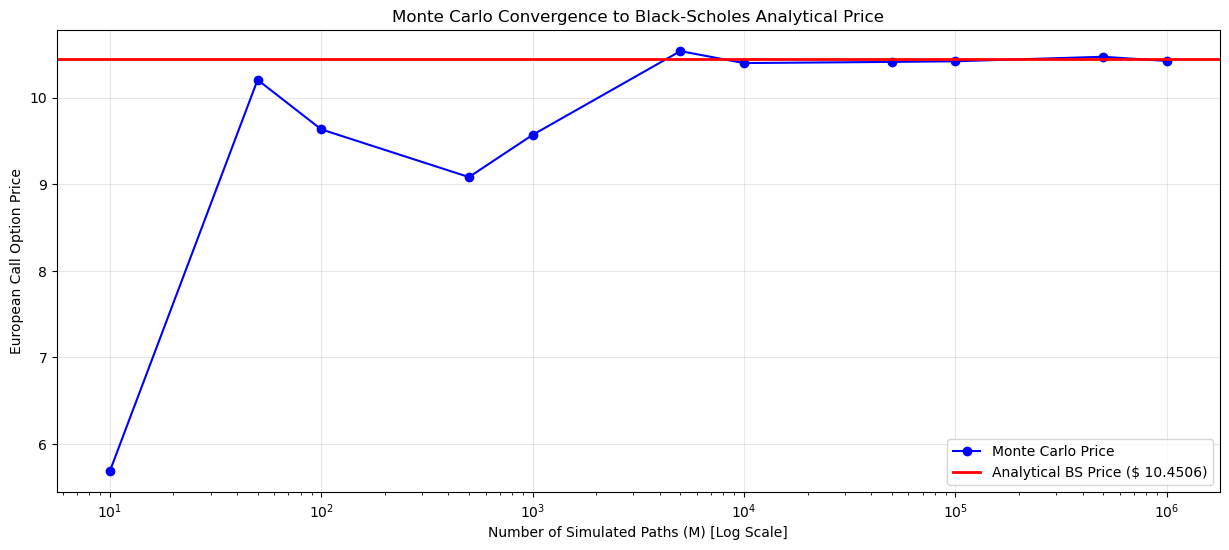

In [28]:
import matplotlib.pyplot as plt
# 1. Define the test variable
s, k, t, r, sig = 100, 100, 1, 0.05, 0.20
analytical_price = black_scholes_call(s, k, t, r, sig)

# 2. Array of increasing path counts (from 10 to 1,000,000)
m_values = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000, 500000, 1000000]
mc_prices = []

# 3. Running the Monte Carlo simulation for each M
for m in m_values:
    mc_prices.append(monte_carlo_call(s, k, t, r, sig, m))

# 4. Visualization
plt.figure(figsize=(15,6))

plt.plot(m_values, mc_prices, marker = 'o', linestyle = '-', color = 'blue', label='Monte Carlo Price')
plt.axhline(y=analytical_price, color= 'red', linewidth= 2, label = f'Analytical BS Price (${analytical_price: .4f})')

plt.xscale('log')
plt.xlabel('Number of Simulated Paths (M) [Log Scale]')
plt.ylabel('European Call Option Price')
plt.title('Monte Carlo Convergence to Black-Scholes Analytical Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Convergence_Plot", dpi = 300, bbox_inches='tight')
plt.show()

### Analyzing Monte Carlo Convergence and Black-Scholes Analytical Price for different volatility levels

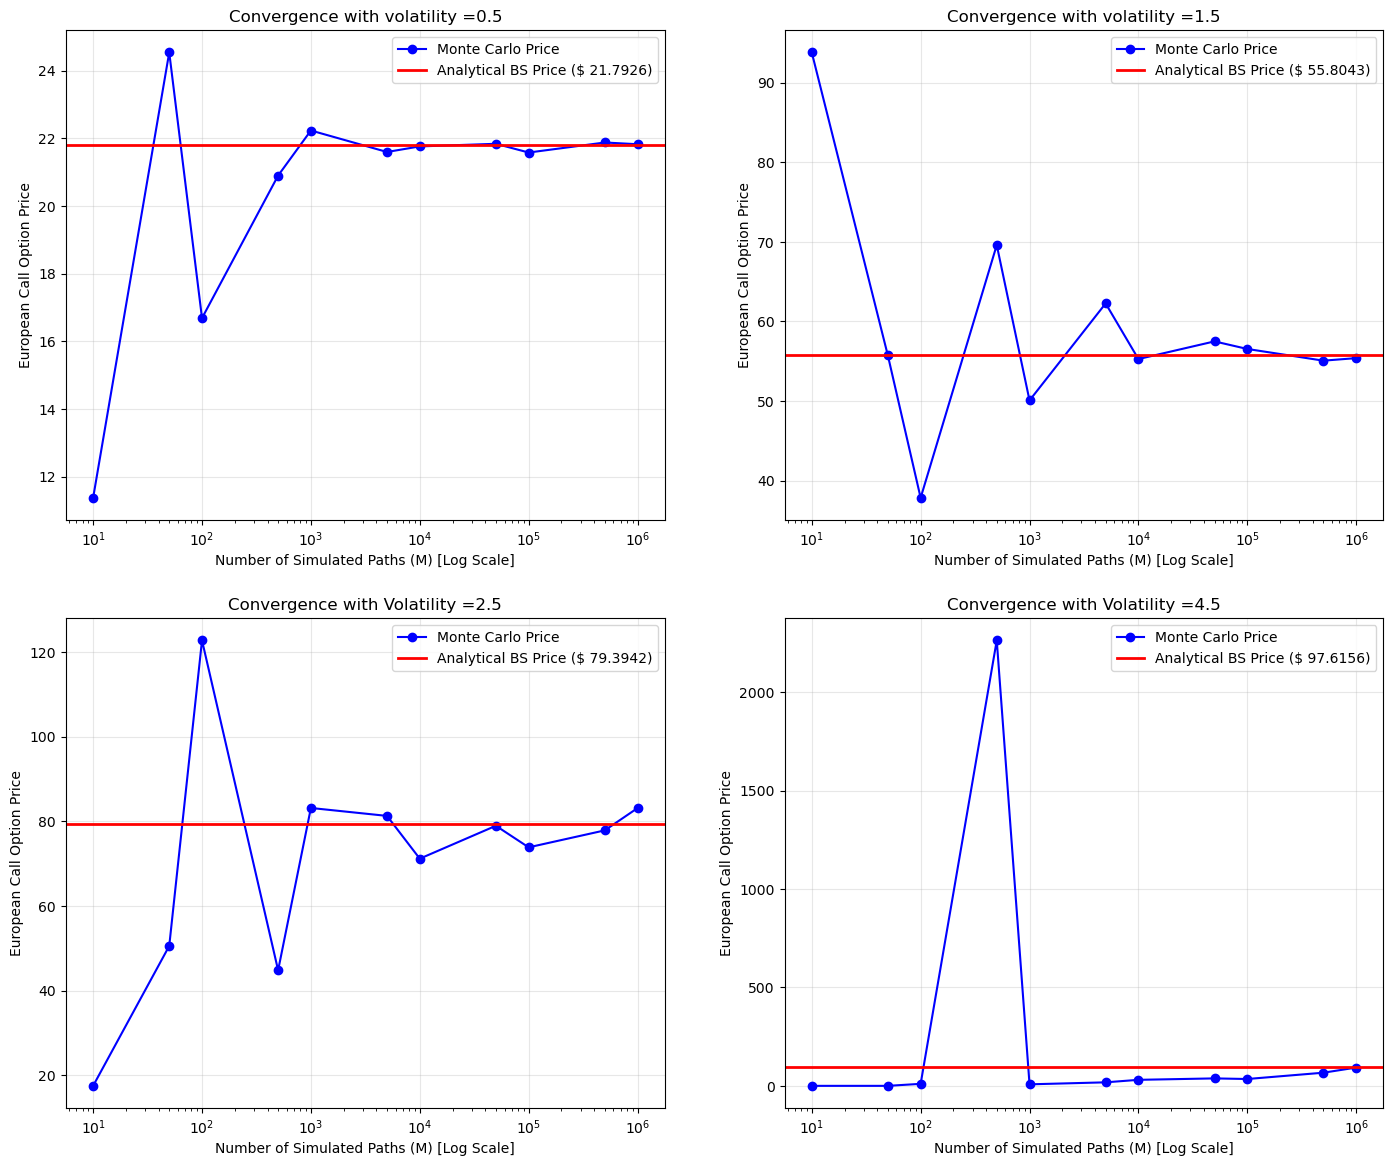

In [29]:
# sigma values
sigm = [0.50, 1.50, 2.50, 4.50]

# Visualization
fig, ax = plt.subplots(2, 2, figsize=(17, 14))
# Running the Monte Carlo simulation for different sigma levels
for si in sigm:
    
    analytical_price1 = black_scholes_call(s, k, t, r, si)
    mc_prices1 = []
    for m in m_values:
        mc_prices1.append(monte_carlo_call(s, k, t, r, si, m))
    if sigm.index(si) < 2:
        i = 0
        j = 1 if sigm.index(si) == 1 else 0
        ax[i,j].plot(m_values, mc_prices1, marker = 'o', linestyle = '-', color = 'blue', label='Monte Carlo Price')
        ax[i,j].axhline(y=analytical_price1, color= 'red', linewidth= 2, label = f'Analytical BS Price (${analytical_price1: .4f})')
        ax[i,j].set_xscale('log')
        ax[i,j].set_xlabel('Number of Simulated Paths (M) [Log Scale]')
        ax[i,j].set_ylabel('European Call Option Price')
        ax[i,j].set_title(f'Convergence with volatility ={si}')
        ax[i,j].legend()
        ax[i,j].grid(True, alpha=0.3) 
    else:
        i = 1
        j = 0 if sigm.index(si) == 2 else 1
        ax[i,j].plot(m_values, mc_prices1, marker = 'o', linestyle = '-', color = 'blue', label='Monte Carlo Price')
        ax[i,j].axhline(y=analytical_price1, color= 'red', linewidth= 2, label = f'Analytical BS Price (${analytical_price1: .4f})')
        ax[i,j].set_xscale('log')
        ax[i,j].set_xlabel('Number of Simulated Paths (M) [Log Scale]')
        ax[i,j].set_ylabel('European Call Option Price')
        ax[i,j].set_title(f'Convergence with Volatility ={si}')
        ax[i,j].legend()
        ax[i,j].grid(True, alpha=0.3)

plt.savefig("volatility_Comparison", dpi = 300, bbox_inches='tight')
plt.show()